# Phase 4 — multi-objective BO panel shape optimization (V1-slim Stage 2)

**Dual-mode**: runs on **Colab** (CPU — SU2 is single-threaded) or **locally** (macOS SU2 via Rosetta). Auto-detects.

Thin orchestration only — all logic is tested library code in `fanopt.bo.{codec,objective,inertia,structural,backbone,orchestration}` + `scripts/run_phase4_bo.py` (CLAUDE.md §6). Each design: decode → Path A+ 2D slice → unsteady SU2 → `J_fan`, plus CadQuery `I_wrist` and plate-bending panel stiffness. The **qLogNEHVI + TuRBO** campaign returns the 3-objective Pareto front (airflow ↑, inertia ↓, deflection ↓).


## 1. Repo + Python/native deps


In [ ]:
import importlib.util
import subprocess
import sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    REPO_DIR = Path("/content/fan-optimization")
    BRANCH = "main"
    REPO_URL = "https://github.com/clingergab/fan-optimization.git"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", BRANCH], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", BRANCH], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "origin", BRANCH], check=True)
    # gmsh dlopens libGLU + X libs at import; Colab CPU runtimes lack them.
    subprocess.run(
        "apt-get install -qq -y libglu1-mesa libxrender1 libxcursor1 "
        "libxft2 libxinerama1 unzip".split(),
        check=True,
    )
    # Phase 4 needs the BO stack (botorch) on top of the geometry/CFD deps.
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "gmsh", "cadquery", "scipy", "jinja2", "pyyaml", "botorch"],
        check=True,
    )
else:
    REPO_DIR = Path.cwd()
    while REPO_DIR != REPO_DIR.parent and not (REPO_DIR / "pyproject.toml").exists():
        REPO_DIR = REPO_DIR.parent

for p in (REPO_DIR / "src", REPO_DIR / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

assert (REPO_DIR / "scripts" / "run_phase4_bo.py").exists(), \
    "phase-4 code missing — is the branch pushed?"

# Preflight: Phase 4 needs cadquery (I_wrist) + gmsh (slice mesh) + botorch (BO).
# Fail here with a clear message rather than a cryptic ModuleNotFoundError deep in
# an import chain when the notebook is running on the wrong kernel/interpreter.
_missing = [m for m in ("cadquery", "gmsh", "botorch", "scipy", "yaml")
            if importlib.util.find_spec(m) is None]
if _missing:
    raise ModuleNotFoundError(
        f"Missing {_missing} in this kernel:\n  {sys.executable}\n"
        "Phase 4 needs cadquery + gmsh + botorch + scipy + pyyaml.\n"
        "  • Local (VSCode): pick the kernel whose interpreter is the one with these "
        "installed (e.g. 'fanopt-local' → /usr/local/bin/python3), or "
        "`<that-python> -m pip install -e '.[bo]' cadquery gmsh`.\n"
        "  • Colab: re-run this cell — the IN_COLAB branch pip-installs them."
    )
print("repo:", REPO_DIR, "| colab:", IN_COLAB, "| deps OK:", sys.executable)


## 2. SU2 — install (Colab) or locate (local)


In [ ]:
import importlib.util
import os
import subprocess
import urllib.request
from pathlib import Path

if importlib.util.find_spec("google.colab") is not None:
    SU2_VERSION = "8.0.1"
    SU2_DIR = Path("/content/su2")
    if not any(SU2_DIR.rglob("SU2_CFD")):
        url = (
            f"https://github.com/su2code/SU2/releases/download/"
            f"v{SU2_VERSION}/SU2-v{SU2_VERSION}-linux64.zip"
        )
        print("[su2] downloading", url)
        urllib.request.urlretrieve(url, "/tmp/su2.zip")
        SU2_DIR.mkdir(parents=True, exist_ok=True)
        subprocess.run(["unzip", "-q", "-o", "/tmp/su2.zip", "-d", str(SU2_DIR)], check=True)
    cands = [p for p in SU2_DIR.rglob("SU2_CFD") if p.is_file() and not p.is_symlink()]
    assert cands, "SU2_CFD not found after extract — see colab_spike_0_6c.ipynb"
    bindir = cands[0].parent
    for p in bindir.iterdir():
        if p.is_file():
            os.chmod(p, 0o755)
else:
    bindir = Path.home() / "su2-local" / "extracted" / "bin"
    assert (bindir / "SU2_CFD").exists(), f"SU2_CFD not at {bindir}"

os.environ["SU2_RUN"] = str(bindir)
os.environ["PATH"] = str(bindir) + os.pathsep + os.environ.get("PATH", "")
print("SU2_RUN:", os.environ["SU2_RUN"])


## 3. Run the BO campaign

The notebook demo runs a **tiny** campaign (3 seeds + 1 BO iteration ≈ 4 CFD evals, ~7 min local) so it completes interactively. A real ranking scales `n_init`/`n_iterations` up and uses the production unsteady resolution.


In [3]:
import run_phase4_bo as script
from fanopt.bo.orchestration import CampaignConfig

# DEMO campaign: 3 Sobol seeds + 1 BO iteration at the fast unsteady resolution
# (~1:45/CFD eval locally). For the real ranking, scale up n_init / n_iterations
# and pass eval_cfg=PRODUCTION_EVAL_CFG (5 cycles, dt=T/200) — see run_phase4_bo --production.
WORK = REPO_DIR / "data" / "phase4_bo_nb"
cfg = CampaignConfig(
    n_init=3, n_iterations=1, seed=0, stall_patience=5,
    num_restarts=4, raw_samples=32, mc_samples=32,
)
summary = script.run(out_dir=WORK, cfg=cfg, su2_bin=None)
print("evals =", summary["n_evaluations"],
      "| pareto =", summary["n_pareto"],
      "| fallback =", summary["used_fallback"])
summary["pareto"][:2]


evals = 4 | pareto = 3 | fallback = 0


[{'vector': [0.00356093674749136,
   0.003690185607969761,
   0.0027803481444716453,
   0.002783280256390572,
   0.002423912747204304,
   0.003097124069929123,
   0.002876055382192135,
   0.0028227399438619616,
   0.0024988409772515297,
   0.003584928119182587,
   0.0036002431869506836,
   0.0037914516270160675,
   0.0034968592032790183,
   0.003524764993786812,
   0.0030307803452014922,
   0.0035784944638609885,
   0.0024825910225510597,
   0.002339245164394379,
   0.0004491292074322701,
   0.7298862263560295,
   5.407179750146217,
   0.9468101571634526,
   0.004886986478231848,
   0.00019761966541409492,
   0.0035226873820647596,
   0.0676767288080378,
   -0.07862818783994713,
   0.5009759562090039],
  'j_fan': -40506313373.75,
  'i_wrist_kgm2': 0.007802471871770916,
  'structural_m': 0.0005901170639135441,
  'blade_count': 8},
 {'vector': [0.002337179374694824,
   0.0029724156647920608,
   0.0030506884530186653,
   0.00335877825319767,
   0.003472641570866108,
   0.00224716239720583

## 4. Pareto front


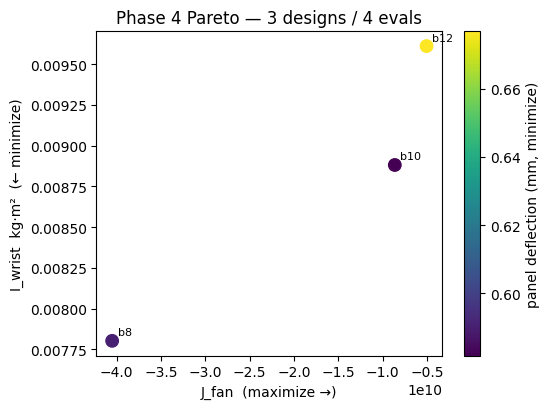

In [4]:
import json
import matplotlib.pyplot as plt

data = json.loads((WORK / "pareto.json").read_text())
pf = data["pareto"]
j = [d["j_fan"] for d in pf]
iw = [d["i_wrist_kgm2"] for d in pf]
st = [d["structural_m"] * 1000.0 for d in pf]  # mm

fig, ax = plt.subplots(figsize=(5.6, 4.2))
sc = ax.scatter(j, iw, c=st, s=80, cmap="viridis")
for d in pf:
    ax.annotate(f"b{d['blade_count']}", (d["j_fan"], d["i_wrist_kgm2"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("J_fan  (maximize →)")
ax.set_ylabel("I_wrist  kg·m²  (← minimize)")
fig.colorbar(sc, label="panel deflection (mm, minimize)")
ax.set_title(f"Phase 4 Pareto — {data['n_pareto']} designs / {data['n_evaluations']} evals")
fig.tight_layout()
plt.show()
